In [2]:
# 1. Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway, kruskal

In [3]:
# 2. Load CSVs
benin = pd.read_csv('../data/benin_clean.csv')
togo = pd.read_csv('../data/togo_clean.csv')
sl = pd.read_csv('../data/sierra_leone_clean.csv')

# Add country column
benin["Country"] = "Benin"
togo["Country"] = "Togo"
sl["Country"] = "Sierra Leone"

# Combine into one DataFrame
df = pd.concat([benin, togo, sl], ignore_index=True)

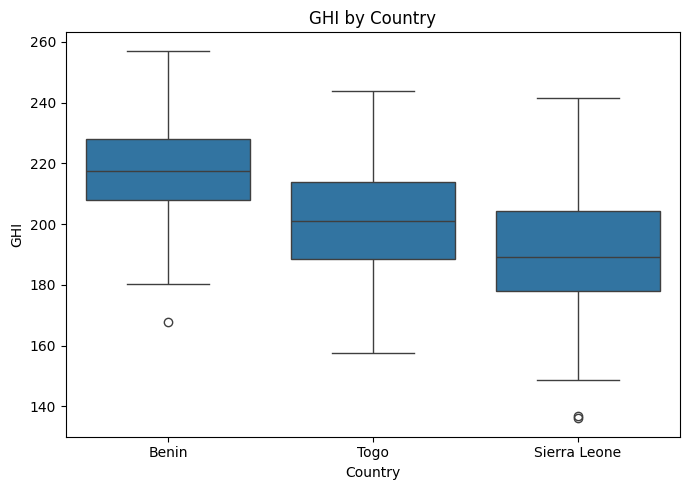

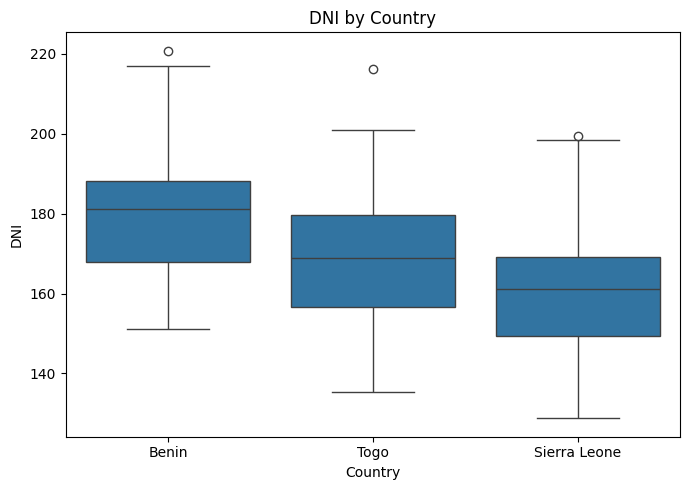

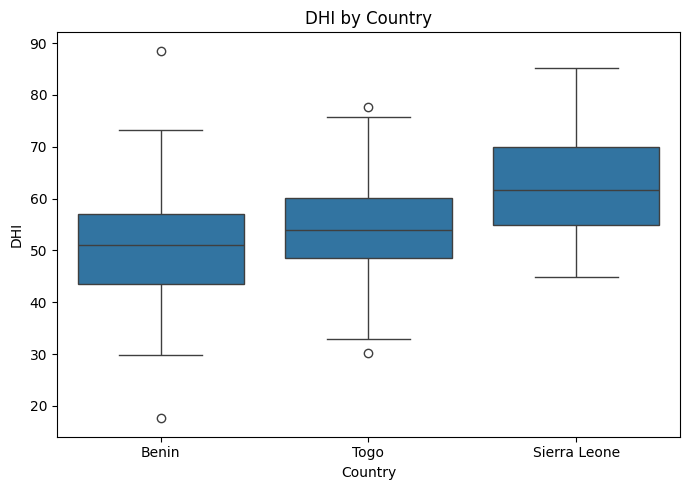

In [4]:
# 3. Boxplots for GHI, DNI, DHI
metrics = ['GHI', 'DNI', 'DHI']
for metric in metrics:
    plt.figure(figsize=(7, 5))
    sns.boxplot(data=df, x='Country', y=metric)
    plt.title(f'{metric} by Country')
    plt.tight_layout()
    plt.show()

In [5]:
# 4. Summary Table
summary = df.groupby("Country")[['GHI', 'DNI', 'DHI']].agg(['mean', 'median', 'std']).round(2)
summary

GHI                    DNI                   DHI         \
                mean  median    std    mean  median    std   mean median   
Country                                                                    
Benin         217.92  217.46  18.16  180.33  181.26  14.31  50.65  50.98   
Sierra Leone  190.48  189.13  21.34  159.91  161.08  14.62  62.29  61.57   
Togo          202.14  201.00  17.68  169.16  168.86  15.96  53.85  53.89   

                     
                std  
Country              
Benin         10.84  
Sierra Leone   9.37  
Togo           9.24

In [6]:
# 5. Statistical Testing - One-way ANOVA
f_val, p_val = f_oneway(
    benin["GHI"],
    togo["GHI"],
    sl["GHI"]
)
print(f"ANOVA p-value for GHI: {p_val:.4f}")
# (Optional) Kruskal–Wallis Test if data is not normal
h_val, p_kw = kruskal(
    benin["GHI"],
    togo["GHI"],
    sl["GHI"]
)
print(f"Kruskal–Wallis p-value for GHI: {p_kw:.4f}")

ANOVA p-value for GHI: 0.0000
Kruskal–Wallis p-value for GHI: 0.0000


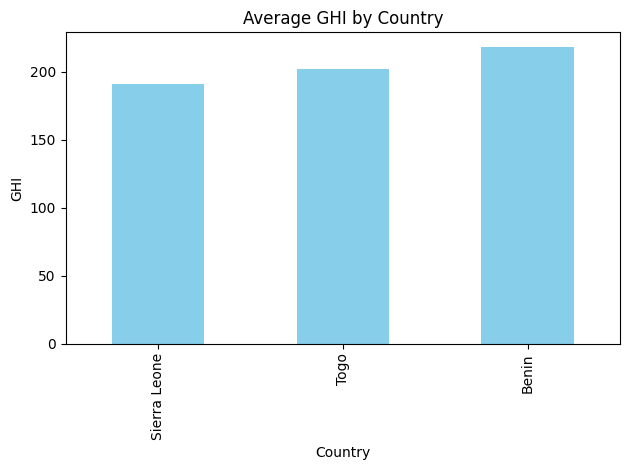

In [7]:
# 6. Bar Chart: Average GHI
df.groupby('Country')["GHI"].mean().sort_values().plot(kind='bar', color='skyblue')
plt.title("Average GHI by Country")
plt.ylabel("GHI")
plt.tight_layout()
plt.show()

# 7. Key Observations

- Benin has the highest average GHI, making it the most promising for solar energy.
- Sierra Leone has the greatest variability in GHI values, suggesting less reliability.
- Togo has moderate and more consistent solar values across all metrics.